# Aircraft Data Hierarchy Nacelle Demonstration

## Purpose

The Nacelle Demo v2 is designed to demonstrate the process of loading, manipulating, and visualizing the geometry of a nacelle component within an aircraft system. This demonstration showcases the use of Pydantic models for data validation and parsing, as well as the traversal and modification of nested attributes within a complex data hierarchy.

## Summary of Demo

### JSON Data Loading
The demonstration begins by loading a JSON file [aircraft_system.json](aircraft_system.json) that contains the hierarchical data structure of an aircraft system, including the nacelle component.

### Pydantic Models
The JSON data is parsed into Pydantic models to ensure data validation and to facilitate easy access and manipulation of the nested attributes.

### Attribute Traversal and Modification
The demonstration includes functions to traverse and modify nested attributes within the Pydantic models, handling both dictionaries and Pydantic objects.

### Geometry Scaling
The nacelle geometry is extracted, scaled by a specified factor, and then updated within the data hierarchy.

### Visualization
The scaled nacelle geometry is visualized using Matplotlib to provide a graphical representation of the changes.

## Example ADH JSON file

File [aircraft_system.json](aircraft_system.json) is an example ADH JSON file for testing. Below is a copy of the Nacelle section of the JSON file. This is only a subsection of the full input file and intended for demonstrating the Nacelle definition.

```json
{
  "AircraftSystem": {
    "wbs_no": "1.0",
    "AirVehicle": {
      "Airframe": {
        "Nacelle": {
          "wbs_no": "1.2.2.5",
          "BasicStructure": {
            "wbs_no": "1.2.2.5.1",
          "geometry": {
            "reference_axis": {
              "points": [
                {"x": 1.0, "y": 1.0, "z": 1.0},
                {"x": 1.0, "y": 1.0, "z": 1.0},
                {"x": 1.0, "y": 1.0, "z": 1.0}
              ],
              "degree": 3
            },
            "cross_sections": [
              {
                "station": 0.0,
                "upper_curve": {
                  "points": [
                    {"x": 0.0, "y": 0.5, "z": 0.0},
                    {"x": 0.0, "y": 0.0, "z": 0.4},
                    {"x": 0.0, "y": -0.5, "z": 0.0}
                  ],
                  "degree": 3
                },
                "lower_curve": {
                  "points": [
                    {"x": 0.0, "y": 0.5, "z": 0.0},
                    {"x": 0.0, "y": 0.0, "z": -0.4},
                    {"x": 0.0, "y": -0.5, "z": 0.0}
                  ],
                  "degree": 3
                }
              },
              {
                "station": 1.0,
                "upper_curve": {
                  "points": [
                    {"x": 0.5, "y": 0.5, "z": 0.0},
                    {"x": 0.5, "y": 0.0, "z": 0.5},
                    {"x": 0.5, "y": -0.5, "z": 0.0}
                  ],
                  "degree": 3
                },
                "lower_curve": {
                  "points": [
                    {"x": 0.5, "y": 0.5, "z": 0.0},
                    {"x": 0.5, "y": 0.0, "z": -0.5},
                    {"x": 0.5, "y": -0.5, "z": 0.0}
                  ],
                  "degree": 3
                }
              },
              {
                "station": 2.0,
                "upper_curve": {
                  "points": [
                    {"x": 1.0, "y": 0.5, "z": 0.0},
                    {"x": 1.0, "y": 0.0, "z": 0.3},
                    {"x": 1.0, "y": -0.5, "z": 0.0}
                  ],
                  "degree": 3
                },
                "lower_curve": {
                  "points": [
                    {"x": 1.0, "y": 0.5, "z": 0.0},
                    {"x": 1.0, "y": 0.0, "z": -0.3},
                    {"x": 1.0, "y": -0.5, "z": 0.0}
                  ],
                  "degree": 3
                }
              }
            ]
          },
          "parameters": {
            "length": 2.0,
            "diameter": 1.0,
            "material": "Aluminum Alloy",
            "weight": 500.0
          },
          "metadata": {
            "key": "nacelle_metadata",
            "value": "Example metadata for nacelle"
          }
        }
    }
  }
}
```

## Helper Functions

In [1]:
import json
import pprint
from typing import Any, Dict
from pydantic import ValidationError
import matplotlib.pyplot as plt
from aircraft_data_hierarchy import AircraftSystem

These functions are included here for now but will eventually make it into the aircraft-data-hierarchy package

In [2]:
# ToDo: Consider moving the next two functions into common_base_model.py
def get_nested_attr(obj: Any, attr: str) -> Any:
    """
    Traverse the object tree using dot notation to get a nested attribute.

    :param obj: The root object to start traversal from.
    :param attr: The dot notation string representing the path to the attribute.
    :return: The value of the nested attribute.
    :raises AttributeError: If any part of the path is invalid.
    """
    try:
        for part in attr.split('.'):
            if isinstance(obj, dict):
                obj = obj[part]
            else:
                obj = getattr(obj, part)
        return obj
    except (AttributeError, KeyError) as e:
        raise AttributeError(f"Failed to get attribute '{attr}': {e}")

def put_nested_attr(obj: Any, attr: str, value: Any) -> None:
    """
    Traverse the object tree using dot notation to put a nested attribute.

    :param obj: The root object to start traversal from.
    :param attr: The dot notation string representing the path to the attribute.
    :param value: The value to set at the nested attribute.
    :raises AttributeError: If any part of the path is invalid.
    """
    try:
        attrs = attr.split('.')
        for part in attrs[:-1]:
            if isinstance(obj, dict):
                obj = obj[part]
            else:
                obj = getattr(obj, part)
        if isinstance(obj, dict):
            obj[attrs[-1]] = value
        else:
            setattr(obj, attrs[-1], value)
    except (AttributeError, KeyError) as e:
        raise AttributeError(f"Failed to put attribute '{attr}': {e}")

def load_aliases(file_path: str) -> Dict[str, str]:
    """
    Load aliases from a file.

    :param file_path: Path to the file containing aliases.
    :return: A dictionary of aliases.
    """
    with open(file_path, 'r') as file:
        aliases = {}
        for line in file:
            key, value = line.strip().split('=')
            aliases[key.strip()] = value.strip().strip('"')  # Remove extra quotes
    return aliases

# Function to scale the nacelle geometry 
def scale_nacelle_geometry(geometry: Dict[str, Any], scale_factor: float) -> Dict[str, Any]:
    def scale_point(point: Dict[str, float]) -> Dict[str, float]:
        return {k: v * scale_factor for k, v in point.items()}
    
    scaled_geometry = geometry.copy()
    scaled_geometry['reference_axis']['points'] = [scale_point(p) for p in geometry['reference_axis']['points']]
    
    for cross_section in scaled_geometry['cross_sections']:
        cross_section['upper_curve']['points'] = [scale_point(p) for p in cross_section['upper_curve']['points']]
        cross_section['lower_curve']['points'] = [scale_point(p) for p in cross_section['lower_curve']['points']]
    
    return scaled_geometry

# Function to draw the nacelle geometry
def draw_nacelle_geometry(geometry: Dict[str, Any]):
    fig, ax = plt.subplots()
    
    # Plot the reference axis
    ref_axis_points = geometry.get('reference_axis', {}).get('points', [])
    if ref_axis_points:
        ref_axis_x = [point['x'] for point in ref_axis_points]
        ref_axis_y = [point['y'] for point in ref_axis_points]
        ax.plot(ref_axis_x, ref_axis_y, label='Reference Axis', color='blue')
    
    # Plot the cross-sections
    cross_sections = geometry.get('cross_sections', [])
    for cross_section in cross_sections:
        station = cross_section.get("station", "Unknown")
        
        if 'upper_curve' in cross_section and cross_section['upper_curve']:
            upper_curve_points = cross_section['upper_curve']['points']
            upper_curve_x = [point['x'] for point in upper_curve_points]
            upper_curve_y = [point['y'] for point in upper_curve_points]
            ax.plot(upper_curve_x, upper_curve_y, label=f'Upper Curve at Station {station}', color='red')
        
        if 'lower_curve' in cross_section and cross_section['lower_curve']:
            lower_curve_points = cross_section['lower_curve']['points']
            lower_curve_x = [point['x'] for point in lower_curve_points]
            lower_curve_y = [point['y'] for point in lower_curve_points]
            ax.plot(lower_curve_x, lower_curve_y, label=f'Lower Curve at Station {station}', color='green')
    
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_title('Nacelle Geometry')
    ax.legend(loc='best', fontsize='small', ncol=2)  # Improved legend
    plt.show()

# Function to extract nacelle geometry
def extract_nacelle_geometry(adh: AircraftSystem, aliases: Dict[str, str]) -> Any:
    nacelle_path = aliases.get("Nacelle")
    if not nacelle_path:
        raise KeyError("Alias for 'Nacelle' not found in aliases.")
    
    # Debug print statement
    print(f"Extracting geometry using path: {nacelle_path}.geometry")
    
    try:
        return get_nested_attr(adh, nacelle_path + ".geometry")
    except AttributeError as e:
        raise AttributeError(f"Error extracting geometry: {e}")
        
# Function to extract nacelle parameters
def extract_nacelle_parameters(adh: AircraftSystem, aliases: Dict[str, str]) -> Any:
    nacelle_path = aliases.get("Nacelle")
    if not nacelle_path:
        raise KeyError("Alias for 'Nacelle' not found in aliases.")
    
    # Debug print statement
    print(f"Extracting parameters using path: {nacelle_path}.parameters")
    
    try:
        return get_nested_attr(adh, nacelle_path + ".parameters")
    except AttributeError as e:
        raise AttributeError(f"Error extracting parameters: {e}")


## Code Implementation

### 1. Loading JSON Data

The JSON file [aircraft_system.json](aircraft_system.json) is loaded into a Python dictionary.

In [3]:
# Load the ADH JSON file
with open('aircraft_system.json', 'r') as file:
    aircraft_system_data = json.load(file)

The JSON data is then parsed into the `AircraftSystem` Pydantic model to ensure data validation and to facilitate easy access to nested attributes.

In [4]:
# Parse the JSON data into the Pydantic model
adh = AircraftSystem.parse_obj(aircraft_system_data)

In [5]:
pprint.pprint(adh.dict(), width=120)

{'AircraftSystem': {'AirVehicle': {'AirVehicleIntegrationAssemblyTestAndCheckout': {'wbs_no': '1.2.1'},
                                   'AirVehicleSoftwareRelease': {'wbs_no': '1.2.9'},
                                   'Airframe': {'AirframeIntegrationAssemblyTestAndCheckout': {'wbs_no': '1.2.2.1'},
                                                'Empennage': {'Stabilizer': {'Ailerons': {'wbs_no': '1.2.2.4.3'},
                                                                             'BasicStructure': {'CenterSection': {'Clips': {'wbs_no': '1.2.2.4.1.1.1.5'},
                                                                                                                  'Ribs': {'wbs_no': '1.2.2.4.1.1.1.3'},
                                                                                                                  'Skins': {'wbs_no': '1.2.2.4.1.1.1.1'},
                                                                                                                  'Spar

### 2. Parsing JSON Data into Pydantic Models

The `AircraftSystem` model is defined using Pydantic, with nested classes representing the hierarchical structure of the aircraft system.

The `Nacelle` class, which inherits from the `Component` class, includes attributes such as geometry, parameters, and metadata.

### 3. Attribute Traversal and Modification

The `get_nested_attr()` function is used to traverse the object tree using dot notation to get a nested attribute. It handles both dictionaries and Pydantic objects.

The `put_nested_attr()` function is used to traverse the object tree using dot notation to set a nested attribute. It also handles both dictionaries and Pydantic objects.

### 4. Extracting and Scaling Nacelle Geometry

In [6]:
# Load aliases from the file
aliases = load_aliases('aircraft_data_hierarchy_aliases.txt')

In [7]:
pprint.pprint(aliases, width=120)

{'AccommodationForPersonnel': 'AircraftSystem.AirVehicle.FurnishingsAndEquipment.AccommodationForPersonnel',
 'AirVehicle': 'AircraftSystem.AirVehicle',
 'AirVehicleAmmunition': 'AircraftSystem.AirVehicle.Ammunition',
 'AirVehicleCargo': 'AircraftSystem.AirVehicle.Cargo',
 'AirVehicleContingency': 'AircraftSystem.AirVehicle.Contingency',
 'AirVehicleExternalUsableFuel': 'AircraftSystem.AirVehicle.ExternalUsableFuel',
 'AirVehicleIntegration': 'AircraftSystem.AirVehicle.AirVehicleIntegrationAssemblyTestAndCheckout',
 'AirVehicleInternalUsableFuel': 'AircraftSystem.AirVehicle.InternalUsableFuel',
 'AirVehicleOperatingItems': 'AircraftSystem.AirVehicle.OperatingItems',
 'AirVehicleOtherAirVehicle': 'AircraftSystem.AirVehicle.OtherAirVehicle',
 'AirVehiclePassengers': 'AircraftSystem.AirVehicle.Passengers',
 'AirVehicleSoftwareRelease': 'AircraftSystem.AirVehicle.AirVehicleSoftwareRelease',
 'AirVehicleTroops': 'AircraftSystem.AirVehicle.Troops',
 'AirVehicleWeapons': 'AircraftSystem.AirVe

The `extract_nacelle_geometry()` function extracts the geometry of the nacelle component using the `get_nested_attr()` function.

In [8]:
# Extract the nacelle parameters
nacelle_parameters = extract_nacelle_parameters(adh, aliases)

Extracting parameters using path: AircraftSystem.AirVehicle.Airframe.Nacelle.parameters


In [9]:
pprint.pprint(nacelle_parameters, width=120)

{'diameter': 1.0, 'length': 2.0, 'material': 'Aluminum Alloy', 'weight': 500.0}


The `scale_nacelle_geometry()` function scales the extracted geometry by a specified factor (e.g., 10%).

In [10]:
# Extract the nacelle geometry
nacelle_geometry = extract_nacelle_geometry(adh, aliases)

Extracting geometry using path: AircraftSystem.AirVehicle.Airframe.Nacelle.geometry


In [11]:
pprint.pprint(nacelle_geometry, width=120)   

{'cross_sections': [{'lower_curve': {'degree': 3,
                                     'points': [{'x': 0.0, 'y': 0.5, 'z': 0.0},
                                                {'x': 0.0, 'y': 0.0, 'z': -0.4},
                                                {'x': 0.0, 'y': -0.5, 'z': 0.0}]},
                     'station': 0.0,
                     'upper_curve': {'degree': 3,
                                     'points': [{'x': 0.0, 'y': 0.5, 'z': 0.0},
                                                {'x': 0.0, 'y': 0.0, 'z': 0.4},
                                                {'x': 0.0, 'y': -0.5, 'z': 0.0}]}},
                    {'lower_curve': {'degree': 3,
                                     'points': [{'x': 0.5, 'y': 0.5, 'z': 0.0},
                                                {'x': 0.5, 'y': 0.0, 'z': -0.5},
                                                {'x': 0.5, 'y': -0.5, 'z': 0.0}]},
                     'station': 1.0,
                     'upper_curve': {'degree

### 5. Updating and Saving the Modified Data

The scaled nacelle geometry is updated within the data hierarchy using the put_nested_attr function.

In [12]:
# Scale the nacelle geometry by 10%
scaled_nacelle_geometry = scale_nacelle_geometry(nacelle_geometry, 1.1)

The updated data hierarchy is saved to a new JSON file (revised_aircraft_system.json).

In [13]:
# Update the ADH with the scaled nacelle geometry
put_nested_attr(adh, aliases["Nacelle"] + ".geometry", scaled_nacelle_geometry)

# Write the updated ADH to a new JSON file
with open('revised_aircraft_system.json', 'w') as file:
    json.dump(adh.dict(), file, indent=4)

### 6. Visualizing the Nacelle Geometry

The `draw_nacelle_geometry()` function visualizes the scaled nacelle geometry using Matplotlib, providing a graphical representation of the reference axis and cross-sections.

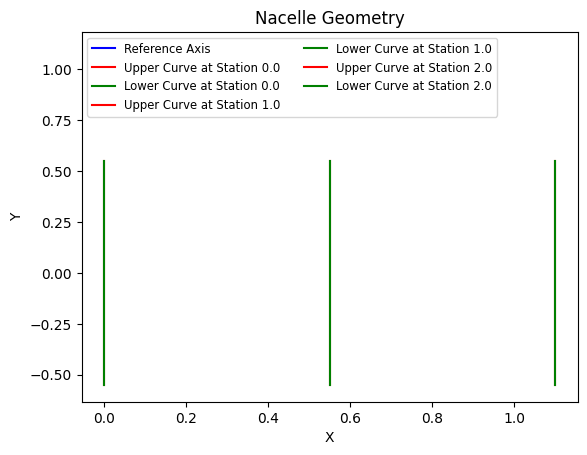

In [14]:
# Draw the scaled nacelle geometry
draw_nacelle_geometry(scaled_nacelle_geometry)

## Conclusion

The Nacelle Demo v2 demonstrates the process of loading, manipulating, and visualizing the geometry of a nacelle component within an aircraft system. By using Pydantic models for data validation and parsing, and by implementing functions to traverse and modify nested attributes, the demonstration provides a comprehensive example of working with complex data hierarchies in Python.